In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
REPO_URL = "https://github.com/kabdoullah/plant-disease-classification.git"
if os.path.exists('/content/project/.git'):
    !git -C /content/project pull
else:
    !git clone {REPO_URL} /content/project

!pip install -q timm

import sys
if '/content/project' not in sys.path:
    sys.path.insert(0, '/content/project')

from src import config
from src.utils import set_seed, get_device, count_parameters, file_size_mb
set_seed(config.SEED)
device = get_device()
print("Device :", device, "|", config.NUM_CLASSES, "classes")

Mounted at /content/drive
Cloning into '/content/project'...
remote: Enumerating objects: 56, done.
remote: Counting objects: 100% (56/56), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 56 (delta 22), reused 45 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (56/56), 19.37 KiB | 9.69 MiB/s, done.
Resolving deltas: 100% (22/22), done.
Device : cpu | 5 classes


In [3]:
import json, numpy as np
from pathlib import Path
from torchvision import datasets
from src.data.loaders import build_transforms, get_dataloaders
from src.models.build import build_model
from src.utils import load_checkpoint

DATA_DIR = "/content/data/tomato5"
if not Path(DATA_DIR).exists():
    !mkdir -p /content/data && unzip -q {config.DRIVE_ROOT}/dataset/tomato5.zip -d /content/data

saved = json.loads((config.RESULTS_DIR / "splits.json").read_text())
splits = {k: saved[k] for k in ("train", "val", "test")}

ds_eval = datasets.ImageFolder(DATA_DIR, transform=build_transforms(False))
test_idx = splits["test"]

models = {}
for kind in ("cnn", "vit"):
    m, _ = build_model(kind, pretrained=False)
    load_checkpoint(config.MODELS_DIR / f"{kind}_best.pt", model=m, device=device)
    models[kind] = m.eval()

preds = np.load(config.RESULTS_DIR / "test_predictions.npz")
y_true, cnn_pred, vit_pred = preds["y_true"], preds["cnn_pred"], preds["vit_pred"]
print("Modèles et prédictions chargés.")

Modèles et prédictions chargés.


In [4]:
ALT = config.CLASSES.index("Tomato___Early_blight")   # classe la plus difficile

def find(mask, n=1):
    return np.where(mask)[0][:n]

cases = {}
# 1. Alternariose correctement classée par les deux
cases["Alternariose — succès partagé"] = find(
    (y_true == ALT) & (cnn_pred == ALT) & (vit_pred == ALT))
# 2. Alternariose ratée par les deux : le cas le plus instructif
cases["Alternariose — échec partagé"] = find(
    (y_true == ALT) & (cnn_pred != ALT) & (vit_pred != ALT))
# 3. Désaccord : ViT correct, CNN faux
cases["Désaccord — ViT correct"] = find(
    (y_true == ALT) & (vit_pred == ALT) & (cnn_pred != ALT))
# 4. Feuille saine (classe facile, référence)
HEALTHY = config.CLASSES.index("Tomato___healthy")
cases["Feuille saine — référence"] = find(
    (y_true == HEALTHY) & (cnn_pred == HEALTHY) & (vit_pred == HEALTHY))

for name, idx in cases.items():
    if len(idx):
        i = idx[0]
        print(f"{name:32s} idx {i:3d} | CNN → {config.CLASSES[cnn_pred[i]]:30s} "
              f"| ViT → {config.CLASSES[vit_pred[i]]}")
    else:
        print(f"{name:32s} aucun exemple trouvé")

Alternariose — succès partagé    idx   1 | CNN → Tomato___Early_blight          | ViT → Tomato___Early_blight
Alternariose — échec partagé     idx  68 | CNN → Tomato___Septoria_leaf_spot    | ViT → Tomato___Bacterial_spot
Désaccord — ViT correct          idx  93 | CNN → Tomato___Bacterial_spot        | ViT → Tomato___Early_blight
Feuille saine — référence        idx   9 | CNN → Tomato___healthy               | ViT → Tomato___healthy


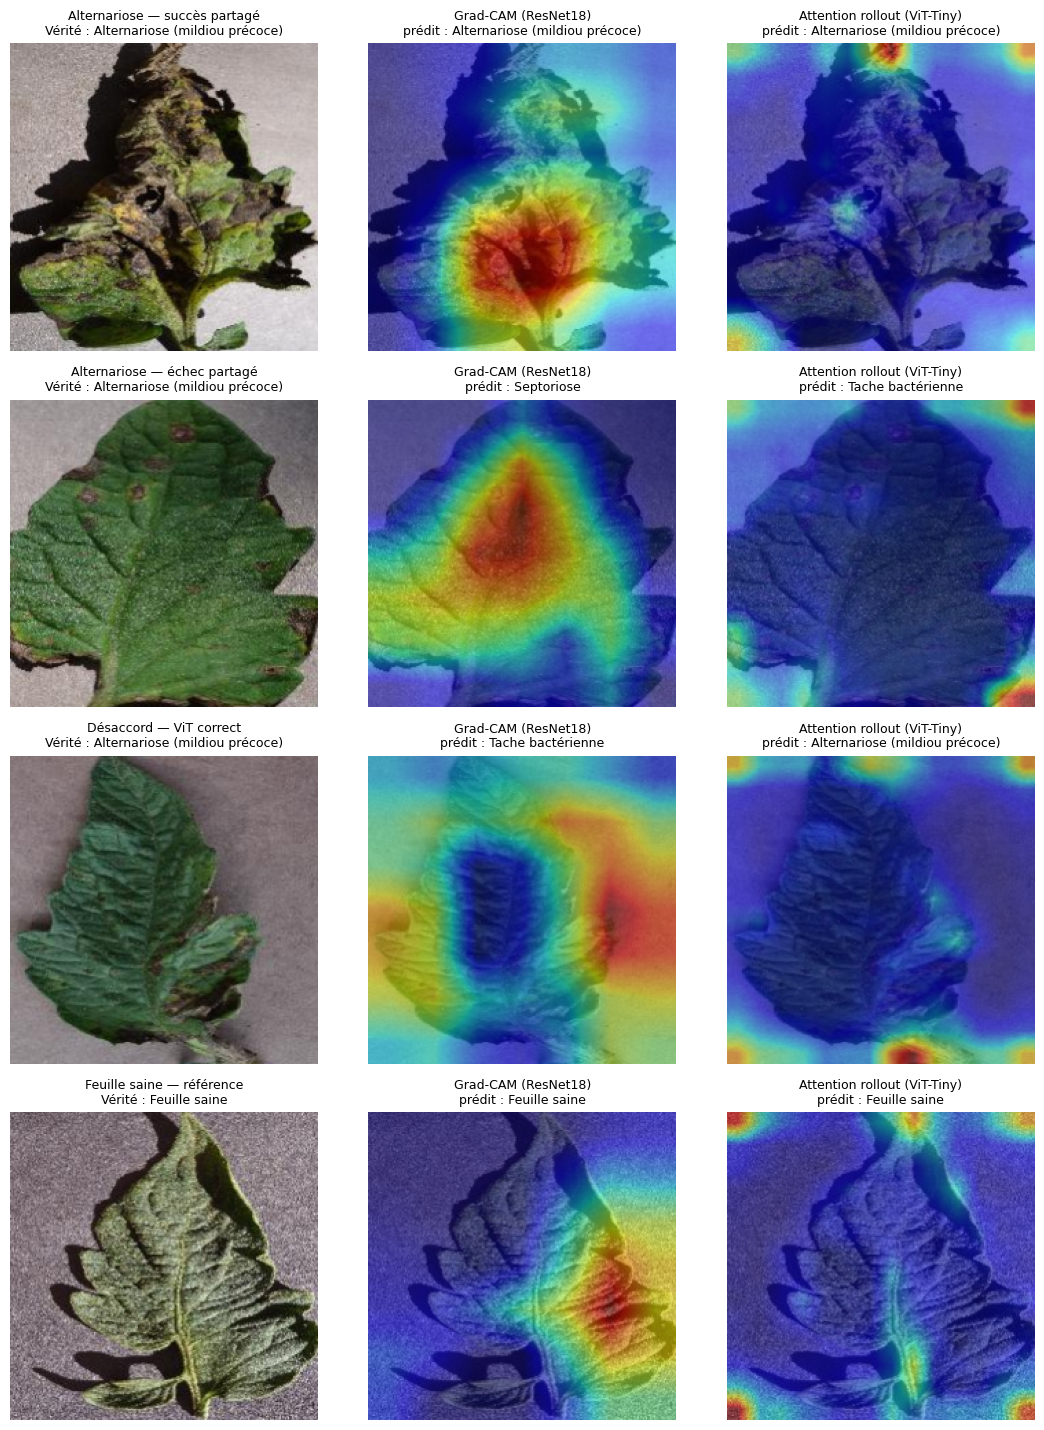

In [5]:
import matplotlib.pyplot as plt
from src.explainability.xai import (gradcam_cnn, attention_rollout_vit,
                                     denormalize, overlay)

FIG_DIR = config.RESULTS_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

selected = [(n, i[0]) for n, i in cases.items() if len(i)]
fig, axes = plt.subplots(len(selected), 3, figsize=(11, 3.6 * len(selected)))
if len(selected) == 1:
    axes = axes[None, :]

for r, (name, local_i) in enumerate(selected):
    tensor, label = ds_eval[test_idx[local_i]]
    img = denormalize(tensor)

    cam, _ = gradcam_cnn(models["cnn"], tensor.to(device),
                         target_class=int(cnn_pred[local_i]))
    att, _ = attention_rollout_vit(models["vit"], tensor.to(device))

    axes[r, 0].imshow(img)
    axes[r, 0].set_title(f"{name}\nVérité : {config.CLASS_LABELS_FR[config.CLASSES[label]]}",
                         fontsize=9)
    axes[r, 1].imshow(overlay(img, cam))
    axes[r, 1].set_title(f"Grad-CAM (ResNet18)\nprédit : "
                         f"{config.CLASS_LABELS_FR[config.CLASSES[cnn_pred[local_i]]]}",
                         fontsize=9)
    axes[r, 2].imshow(overlay(img, att))
    axes[r, 2].set_title(f"Attention rollout (ViT-Tiny)\nprédit : "
                         f"{config.CLASS_LABELS_FR[config.CLASSES[vit_pred[local_i]]]}",
                         fontsize=9)
    for c in range(3):
        axes[r, c].axis("off")

plt.tight_layout()
plt.savefig(FIG_DIR / "interpretabilite.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# Vérifie que l'attention rollout fonctionne hors GPU (l'API tournera sur CPU)
import torch
m_cpu = models["vit"].to(torch.device("cpu"))
tensor, _ = ds_eval[test_idx[0]]
att, pred = attention_rollout_vit(m_cpu, tensor)
print("Rollout CPU OK — carte", att.shape, "| prédiction :", config.CLASSES[pred])
models["vit"].to(device)

Rollout CPU OK — carte (224, 224) | prédiction : Tomato___Bacterial_spot


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)


In [8]:
import numpy as np
preds = np.load(config.RESULTS_DIR / "test_predictions.npz")
from src.evaluation.evaluate import get_confusion
for kind in ("cnn", "vit"):
    print(f"\n=== {kind.upper()} ===")
    print("Ordre :", config.CLASSES)
    print(get_confusion(preds["y_true"], preds[f"{kind}_pred"]))


=== CNN ===
Ordre : ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___healthy']
[[52  3  1  4  0]
 [ 8 43  4  4  1]
 [ 0 17 43  0  0]
 [ 4  6  6 44  0]
 [ 0  0  0  0 60]]

=== VIT ===
Ordre : ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___healthy']
[[58  0  1  1  0]
 [ 6 41  7  4  2]
 [ 1  7 51  0  1]
 [ 5  1  0 53  1]
 [ 0  0  0  1 59]]


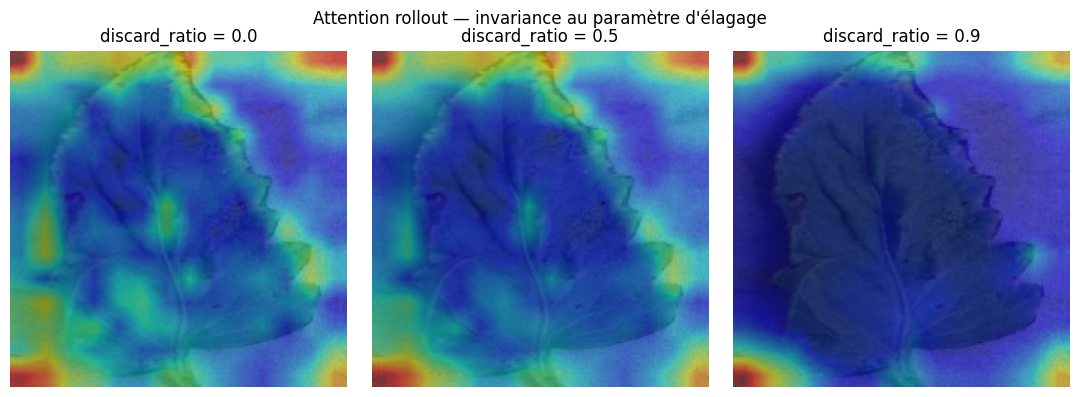

In [8]:
import matplotlib.pyplot as plt
from src.explainability.xai import attention_rollout_vit, denormalize, overlay

tensor, _ = ds_eval[test_idx[0]]
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, ratio in zip(axes, (0.0, 0.5, 0.9)):
    att, _ = attention_rollout_vit(models["vit"], tensor.to(device), discard_ratio=ratio)
    ax.imshow(overlay(denormalize(tensor), att))
    ax.set_title(f"discard_ratio = {ratio}")
    ax.axis("off")
plt.suptitle("Attention rollout — invariance au paramètre d'élagage")
plt.tight_layout()
plt.savefig(config.RESULTS_DIR / "figures" / "ablation_discard_ratio.png", dpi=150)
plt.show()